In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/unsharp_mask/107_unsharp_mask.jpg
/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/unsharp_mask/117_unsharp_mask.jpg
/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/unsharp_mask/126_unsharp_mask.jpg
/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/unsharp_mask/5_unsharp_mask.jpg
/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/unsharp_mask/219_unsharp_mask.jpg
/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/unsharp_mask/6_unsharp_mask.jpg
/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach/Peach___healthy/un

# 🍑 Peach Leaf Disease Classification using Vision Transformer (ViT)

## 📌 Project Overview

This project aims to classify peach leaf diseases using a Vision Transformer (ViT) model. The model learns patterns from leaf images and predicts whether a leaf is healthy or diseased.

### Objectives
- Load and preprocess image data
- Train a Vision Transformer model
- Evaluate model performance
- Visualize results using confusion matrix and classification metrics

# 📚 Import Libraries

In this section, we import all required libraries for:

- Data processing
- Image transformations
- Model building
- Training and evaluation
- Visualization

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

# 📂 Dataset Loading

The dataset contains images of peach leaves belonging to different categories.

### Steps
1. Load images from folders
2. Create dataset object
3. Verify classes and dataset size

# 🖼️ Data Preprocessing

Before training, images must be transformed into a format suitable for the Vision Transformer.

### Applied Transformations
- Resize images to 224×224
- Convert images to tensors
- Normalize pixel values

These transformations help improve model performance and training stability.

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_dir = "/kaggle/input/datasets/shuvokumarbasak2030/peach-leaf-diseases-plant-village-augmented-data/Peach"

full_dataset = datasets.ImageFolder(
    dataset_dir,
    transform=transform
)

print(full_dataset.classes)

['Peach___Bacterial_spot', 'Peach___healthy']


# ✂️ Dataset Splitting

The dataset is divided into:

- Training Set → Used for learning
- Validation Set → Used for monitoring performance
- Test Set → Used for final evaluation

This helps prevent overfitting and provides a reliable performance estimate.

In [4]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size]
)

# 🚚 DataLoader Preparation

PyTorch DataLoaders are created to efficiently load images in batches.

### Benefits
- Faster training
- Reduced memory usage
- Automatic batching and shuffling

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8
)

print(len(train_loader))

3615


In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


# 🧠 Vision Transformer (ViT) Model

A Vision Transformer (ViT) is used for image classification.

### Why ViT?
- Captures global image information
- Strong performance on image classification tasks
- Modern alternative to CNN architectures

The final classification layer is modified according to the number of classes in the dataset.

In [7]:
model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=False
)

model.head = nn.Linear(
    model.head.in_features,
    2
)

model = model.to(device)

print("Model Created Successfully")

Model Created Successfully


# ⚙️ Model Configuration

To train the model:

### Loss Function
CrossEntropyLoss

### Optimizer
Adam Optimizer

The loss function measures prediction errors, while the optimizer updates model weights during training.

# 🚀 Model Training

The model is trained over multiple epochs.

For each epoch:

1. Forward pass
2. Compute loss
3. Backpropagation
4. Update weights

Training loss is recorded to monitor learning progress.

# ✅ Model Validation

After each training epoch, the model is evaluated on the validation dataset.

### Purpose
- Monitor generalization performance
- Detect overfitting
- Track validation accuracy and loss

# 📈 Training Performance

Training and validation metrics are visualized to understand how the model learns over time.

### Metrics
- Training Loss
- Validation Loss
- Accuracy

These graphs help identify underfitting and overfitting.

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

epochs = 3

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):

    # TRAINING
    model.train()

    running_loss = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # VALIDATION
    model.eval()

    val_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(test_loader)

    accuracy = 100 * correct / total

    val_losses.append(avg_val_loss)

    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

    # SAVE MODEL
    torch.save(
        model.state_dict(),
        f"vit_epoch_{epoch+1}.pth"
    )

100%|██████████| 3615/3615 [04:40<00:00, 12.88it/s]


Epoch 1
Train Loss: 0.2084
Validation Loss: 0.1203
Validation Accuracy: 94.94%


100%|██████████| 3615/3615 [03:28<00:00, 17.33it/s]


Epoch 2
Train Loss: 0.1182
Validation Loss: 0.1071
Validation Accuracy: 95.71%


100%|██████████| 3615/3615 [03:47<00:00, 15.92it/s]


Epoch 3
Train Loss: 0.0983
Validation Loss: 0.0945
Validation Accuracy: 96.32%


# 📈 Training Performance

Training and validation metrics are visualized to understand how the model learns over time.

### Metrics
- Training Loss
- Validation Loss
- Accuracy

These graphs help identify underfitting and overfitting.

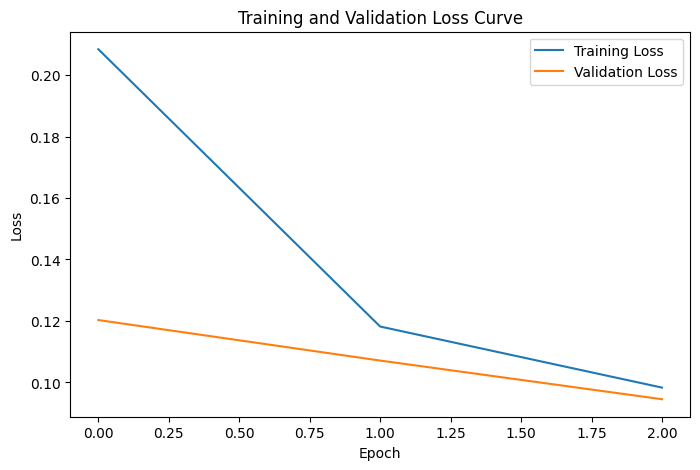

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(np.array(train_losses), label='Training Loss')
plt.plot(np.array(val_losses), label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()

plt.show()

In [12]:
print([name for name in dir() if 'loader' in name.lower() or 'dl' in name.lower()])

['DataLoader', '__loader__', 'test_loader', 'train_loader']


# 🎯 Model Evaluation

The trained model is tested on unseen data.

Evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics provide a complete picture of model performance.

# 📊 Confusion Matrix

The confusion matrix shows how many samples were correctly and incorrectly classified.

### Interpretation

- Diagonal values → Correct predictions
- Off-diagonal values → Incorrect predictions

This helps identify classification weaknesses.

In [15]:
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      6249
           1       0.90      0.82      0.86       980

    accuracy                           0.96      7229
   macro avg       0.93      0.90      0.92      7229
weighted avg       0.96      0.96      0.96      7229



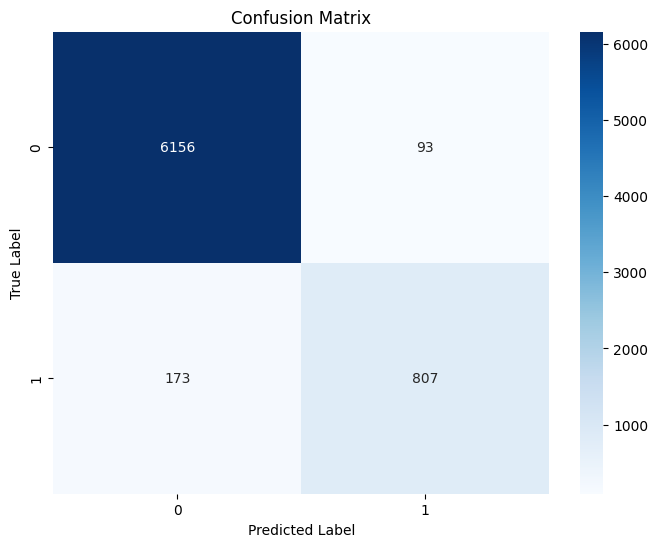

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Print Precision, Recall, and F1-Score
# Note: If 'class_names' gives a NameError, remove the target_names argument
try:
    print("--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))
except NameError:
    print(classification_report(all_labels, all_preds))

# 2. Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))

try:
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
except NameError:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [16]:
print("Number of Classes:", len(full_dataset.classes))
print("Classes:", full_dataset.classes)
print("Total Images:", len(full_dataset))

Number of Classes: 2
Classes: ['Peach___Bacterial_spot', 'Peach___healthy']
Total Images: 36142


# Accuracy Calculation

In [19]:
accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.32%


#  Sample Image Visualization

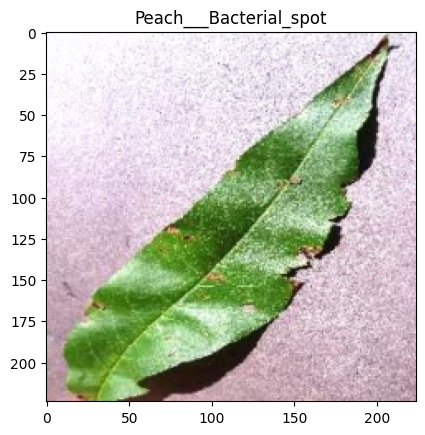

In [20]:
import matplotlib.pyplot as plt

image, label = full_dataset[0]
plt.imshow(image.permute(1,2,0))
plt.title(full_dataset.classes[label])
plt.show()

# 🎉 Conclusion

In this project, a Vision Transformer (ViT) was successfully trained for peach leaf disease classification.

### Achievements
- Preprocessed image dataset
- Trained a ViT model
- Evaluated performance
- Visualized results using confusion matrix and classification metrics

### Future Improvements
- Larger dataset
- Data augmentation
- Hyperparameter tuning
- Model deployment using Streamlit or Flask